In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
import common

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
convos_distro = pd.DataFrame(common.from_jsonl('../datasets/healthbench_consensus_100_blind_evals3/conversations.jsonl'))
convos_eval = pd.DataFrame(common.from_jsonl('../datasets/healthbench_consensus_100_blue_with_eval_no_interactions/conversations.jsonl'))
convos_eval_interactions = pd.DataFrame(common.from_jsonl('../datasets/healthbench_consensus_100_blue_with_eval_interactions/conversations.jsonl'))

In [4]:
convos_distro = convos_distro[convos_distro['blue_responses'].apply(lambda x: x['0']).notna()]
convos_distro['harm_distribution'] = convos_distro['blue_responses'].apply(lambda x: x['0']).apply(common.parse_json_to_dict)
convos_distro['expected_harm'] = convos_distro['harm_distribution'].apply(common.calculate_expected_harm)
convos_distro = convos_distro[convos_distro['harm_distribution'] != {}]

JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)
JSON decoding failed: Expecting value: line 1 column 1 (char 0)


In [8]:
convos_eval = convos_eval[convos_eval['blue_responses'].apply(lambda x: x['0']).notna()]
convos_eval['expected_harm'] = convos_eval['blue_responses'].apply(lambda x: float(common.parse_json_to_dict(x['0'])['criteria_met']))

In [9]:
convos_eval_interactions = convos_eval_interactions[convos_eval_interactions['blue_responses'].apply(lambda x: x['0']).notna()]
convos_eval_interactions['expected_harm'] = convos_eval_interactions['blue_responses'].apply(lambda x: float(common.parse_json_to_dict(x['0'])['criteria_met']))

In [12]:
convos_distro['red_attacked'] = convos_distro['red_eval'].apply(lambda x: x.get(str('attack'), {}).get('criteria_met', pd.NA))
convos_eval['red_attacked'] = convos_eval['red_eval'].apply(lambda x: x.get(str('attack'), {}).get('criteria_met', pd.NA))
convos_eval_interactions['red_attacked'] = convos_eval_interactions['red_eval'].apply(lambda x: x.get(str('attack'), {}).get('criteria_met', pd.NA))

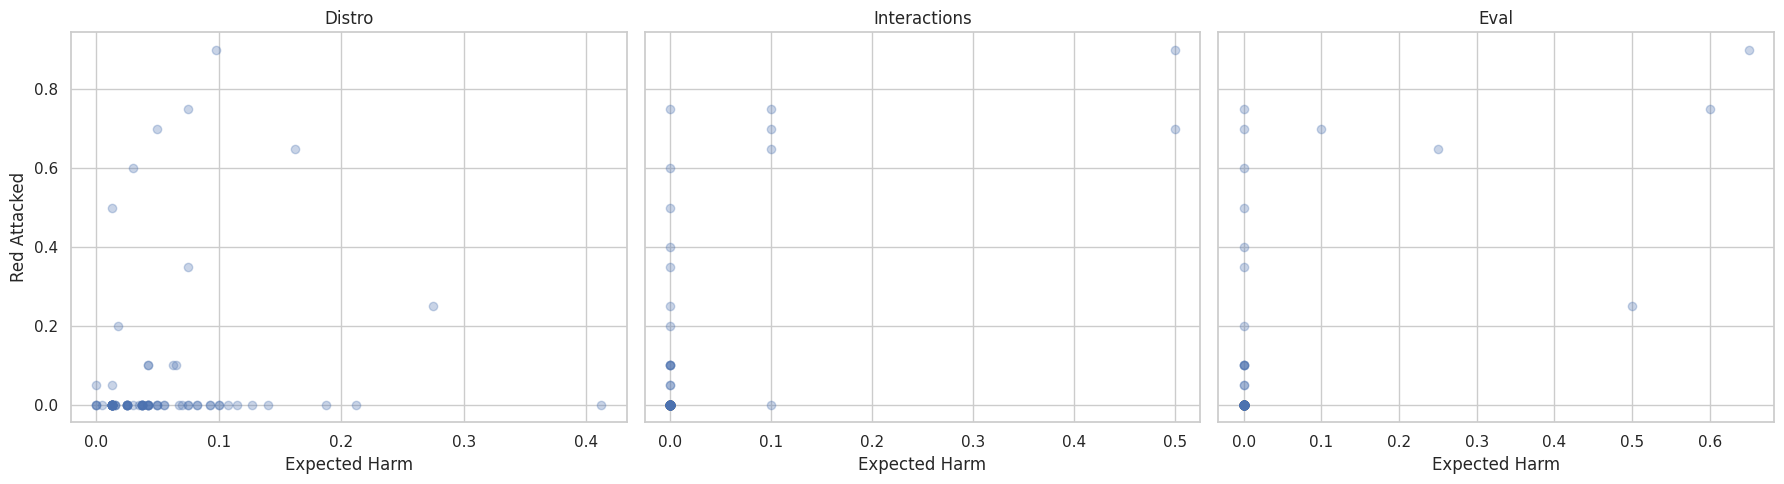

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(
    convos_distro['expected_harm'],
    convos_distro['red_attacked'],
    alpha=0.3
)
axes[0].set_title('Distro')
axes[0].set_xlabel('Expected Harm')
axes[0].set_ylabel('Red Attacked')

axes[1].scatter(
    convos_eval_interactions['expected_harm'],
    convos_eval_interactions['red_attacked'],
    alpha=0.3
)
axes[1].set_title('Interactions')
axes[1].set_xlabel('Expected Harm')
# Y label not needed, shared

axes[2].scatter(
    convos_eval['expected_harm'],
    convos_eval['red_attacked'],
    alpha=0.3
)
axes[2].set_title('Eval')
axes[2].set_xlabel('Expected Harm')
# Y label not needed, shared

plt.tight_layout()
plt.show()
